<a href="https://colab.research.google.com/github/thulasi171998/carbon-emmission-_AICTE/blob/main/Carbon_Emission_India_Colab_AICTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌍 Carbon Emissions Prediction Project (India, 2010–2030)
**Internship Project | Google Colab Ready**

This project uses GDP, Energy Use, and Population to predict India's CO₂ emissions from 2010 to 2030 using **Linear Regression**.

📊 Includes pairplot, heatmap, multicollinearity (VIF), and predictions with graphs.

**Developed for Non-Programmers** — Just run the cells!

In [ ]:
# ✅ Step 1: Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [ ]:
# ✅ Step 2: Create and load the data (CSV is not needed)
from io import StringIO
csv_data = '''Year,GDP,Energy_Use,Population,CO2_Emissions
2010,1675,450,1234,2000
2011,1820,460,1256,2150
2012,1980,470,1278,2290
2013,2100,480,1302,2400
2014,2250,490,1325,2550
2015,2400,500,1349,2700
2016,2550,510,1372,2840
2017,2700,520,1396,2980
2018,2900,540,1419,3150
2019,3100,560,1443,3300
2020,3200,570,1465,3400
2021,3350,580,1488,3550
2022,3500,590,1511,3700
2023,3650,600,1534,3850
2024,3800,610,1557,4000
2025,3950,620,1580,4150
2026,4100,630,1603,4300
2027,4250,640,1626,4450
2028,4400,650,1649,4600
2029,4550,660,1672,4750
2030,4700,670,1695,4900
'''
data = pd.read_csv(StringIO(csv_data))
data.head()

,Year,GDP,Energy_Use,Population,CO2_Emissions
0,2010,1675,450,1234,2000
1,2011,1820,460,1256,2150
2,2012,1980,470,1278,2290
3,2013,2100,480,1302,2400
4,2014,2250,490,1325,2550


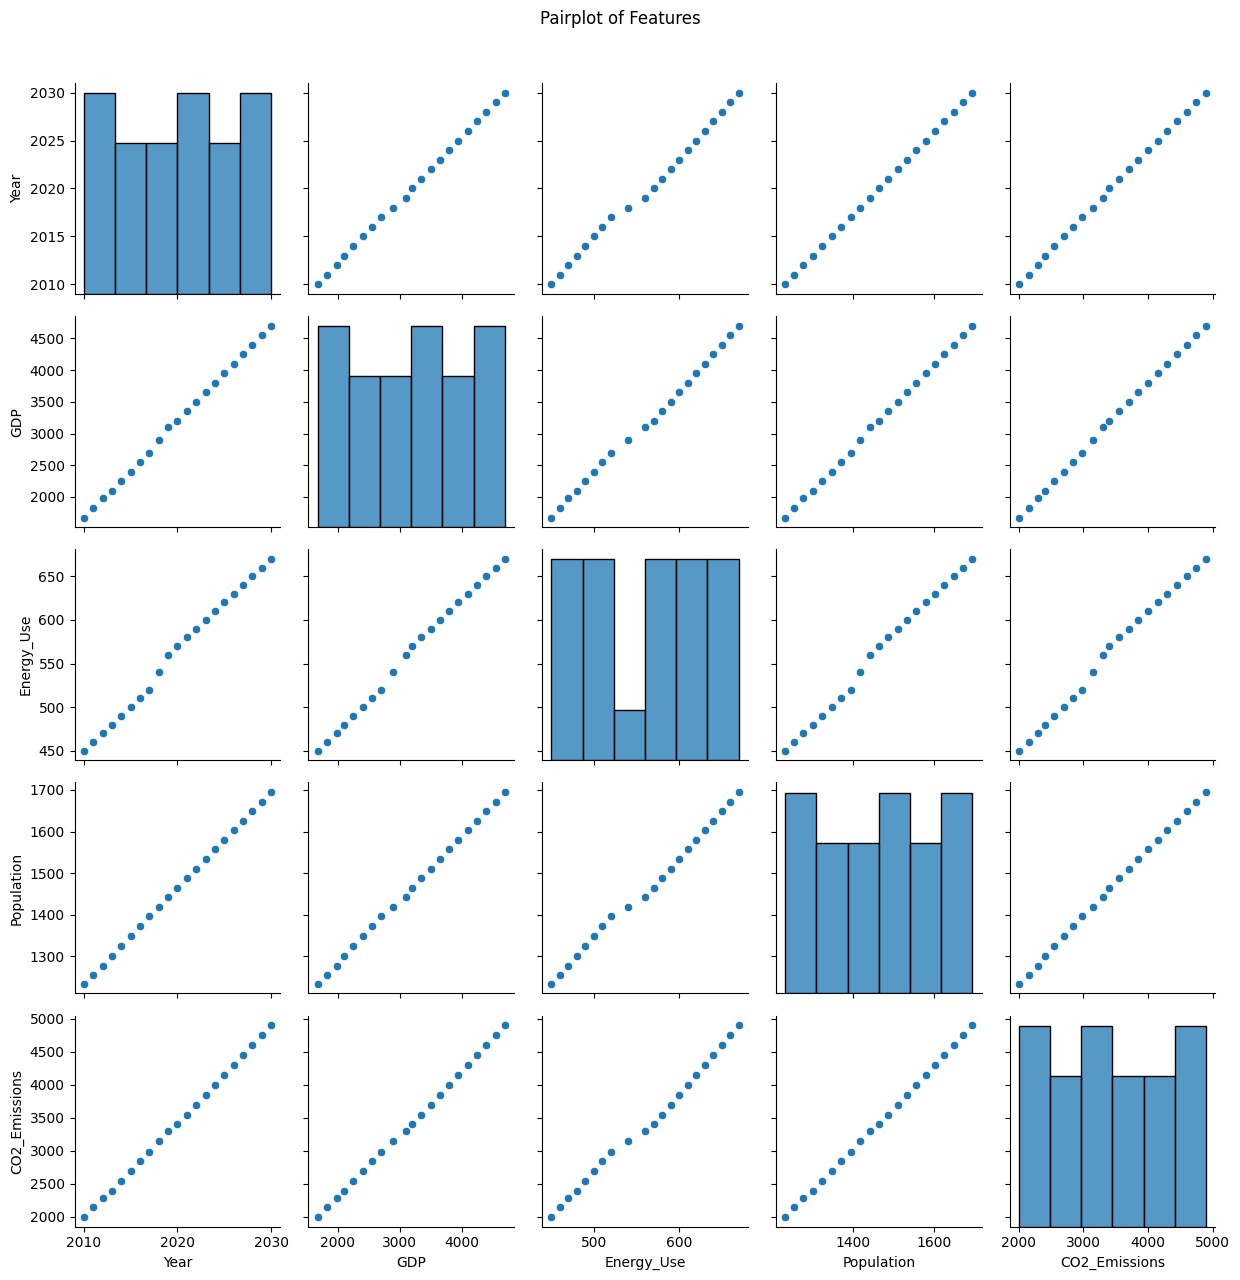

In [ ]:
# ✅ Step 3: Data Visualization - Pairplot
sns.pairplot(data)
plt.suptitle("Pairplot of Features", y=1.02)
plt.tight_layout()
plt.show()

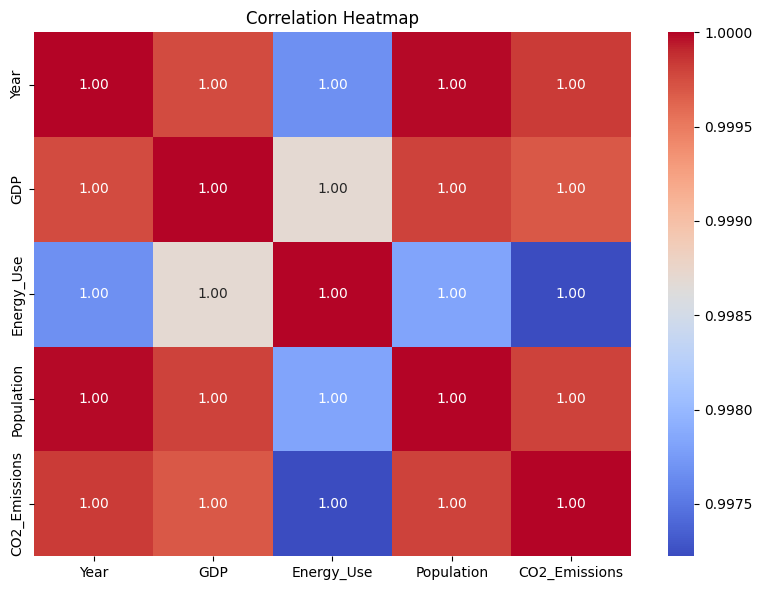

In [ ]:
# ✅ Step 4: Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
# ✅ Step 5: Multicollinearity Check - VIF
X = data[["GDP", "Energy_Use", "Population"]]
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data

,Feature,VIF
0,GDP,412.639315
1,Energy_Use,18257.741672
2,Population,13443.888141


In [ ]:
# ✅ Step 6: Train the Linear Regression Model
y = data["CO2_Emissions"]
model = LinearRegression()
model.fit(X, y)
data["Predicted_CO2"] = model.predict(X)
data[["Year", "CO2_Emissions", "Predicted_CO2"]].head()

,Year,CO2_Emissions,Predicted_CO2
0,2010,2000,1986.292885
1,2011,2150,2128.590448
2,2012,2290,2290.220022
3,2013,2400,2401.180087
4,2014,2550,2550.362914


In [ ]:
# ✅ Step 7: Model Performance
mse = mean_squared_error(y, data["Predicted_CO2"])
r2 = r2_score(y, data["Predicted_CO2"])
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Squared Error: 75.43
R² Score: 1.00


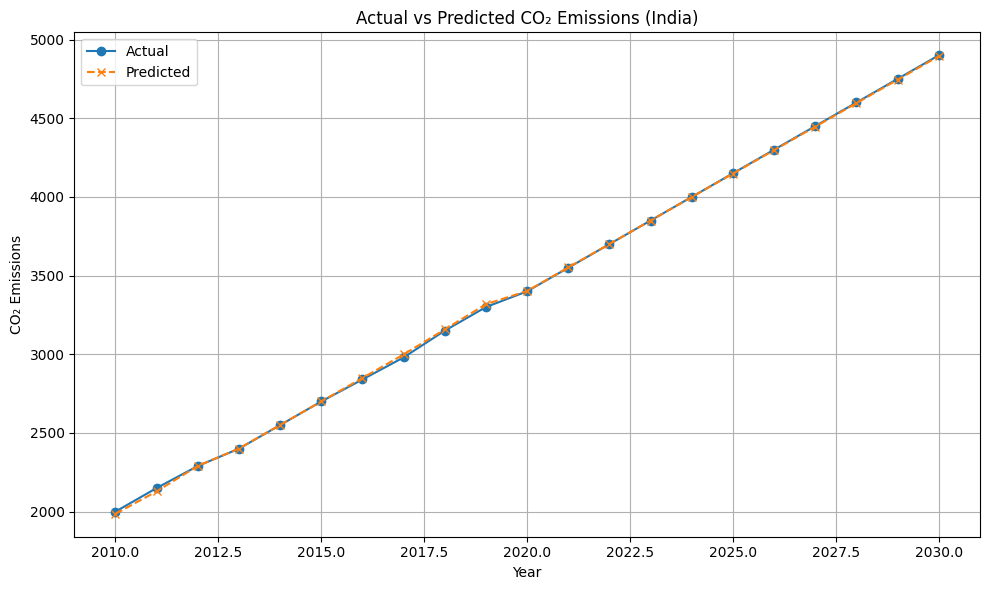

In [ ]:
# ✅ Step 8: Plot Actual vs Predicted CO2 Emissions
plt.figure(figsize=(10,6))
plt.plot(data["Year"], data["CO2_Emissions"], marker='o', label='Actual')
plt.plot(data["Year"], data["Predicted_CO2"], marker='x', linestyle='--', label='Predicted')
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions")
plt.title("Actual vs Predicted CO₂ Emissions (India)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()